# Notebook 6b — Training Dataset Evaluation (PTB-XL Train Split as Test)

Per the spec in NEW_ONE.txt: *'we are also using training dataset as testing dataset  
and results of it like testing curves, F1 scores, accuracy — all those things we want  
separately for each dataset and for cross dataset testing.'*

## What this notebook does
1. ✅ Runs the trained model on the **training split** (not the held-out test split)
2. ✅ Generates **separate** full metric reports for train split
3. ✅ Compares train / val / test / INCART performance side by side
4. ✅ Generates per-class F1, precision, recall bar plots for each split
5. ✅ Calibration curve and reliability diagram for each split
6. ✅ Saves all results into `train_eval_results.json` separately

**Note:** High accuracy on the training split is expected (model has seen these).  
This is a diagnostic tool, not a measure of generalization.


In [ ]:
import torch, sys, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, average_precision_score,
    precision_score, recall_score, roc_curve, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = Path("./ECG_Project/data")
sys.path.insert(0, str(SAVE_DIR))
from ecg_model import ECGRiskNetXAI

with open(SAVE_DIR / "metadata.json") as f: META = json.load(f)
RISK_LABELS = {int(k): v for k, v in META["risk_labels"].items()}

model = ECGRiskNetXAI(in_ch=12, base_ch=64, meta_dim=3, dropout=0.3).to(device)
model.load_state_dict(torch.load(SAVE_DIR / "best_model.pt", map_location=device))
model.eval()
print("✅ Model loaded.")
print(f"Device: {device}")


✅ Model loaded.
Device: cuda


## Utility: Evaluate Any Split

In [9]:
from torch.utils.data import TensorDataset, DataLoader


def evaluate_split(npz_path, split_name, batch_size=64):
    """
    Run the trained model on any split .npz file.
    Returns dict with all metrics + arrays for plotting.
    """
    d = np.load(npz_path)
    X = d["X"].astype(np.float32)     # (N, 1000, 12)
    y = d["y"].astype(np.int64)
    M = d["meta"].astype(np.float32) if "meta" in d else np.zeros((len(y), 3), np.float32)

    # transpose to (N, 12, 1000)
    X_t = torch.from_numpy(X.transpose(0, 2, 1))
    M_t = torch.from_numpy(M)
    y_t = torch.from_numpy(y)

    loader = DataLoader(TensorDataset(X_t, M_t, y_t),
                        batch_size=batch_size, shuffle=False,
                        num_workers=0, pin_memory=True)

    all_preds, all_probs, all_true = [], [], []
    model.eval()
    with torch.no_grad():
        for xb, mb, yb in loader:
            out   = model(xb.to(device), mb.to(device))
            probs = torch.softmax(out["risk"], dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            all_preds.extend(preds)
            all_probs.append(probs)
            all_true.extend(yb.numpy())

    preds = np.array(all_preds)
    true  = np.array(all_true)
    probs = np.vstack(all_probs)

    acc   = (preds == true).mean()
    mf1   = f1_score(true, preds, average="macro",    zero_division=0)
    wf1   = f1_score(true, preds, average="weighted",  zero_division=0)
    mcc   = matthews_corrcoef(true, preds)
    kappa = cohen_kappa_score(true, preds)

    per_class_f1   = f1_score(true, preds, average=None, zero_division=0, labels=[0,1,2,3])
    per_class_prec = precision_score(true, preds, average=None, zero_division=0, labels=[0,1,2,3])
    per_class_rec  = recall_score(true, preds, average=None, zero_division=0, labels=[0,1,2,3])

    roc_auc, pr_auc = 0.0, 0.0
    try:
        y_bin   = label_binarize(true, classes=[0,1,2,3])
        roc_auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr", labels=[0,1,2,3])
        pr_auc  = np.mean([average_precision_score(y_bin[:, k], probs[:, k]) for k in range(4)])
    except Exception:
        pass

    print(f"\n{'='*55}")
    print(f"  {split_name} Results")
    print(f"{'='*55}")
    print(f"  Accuracy    : {acc*100:.2f}%")
    print(f"  Macro F1    : {mf1:.4f}")
    print(f"  Weighted F1 : {wf1:.4f}")
    print(f"  MCC         : {mcc:.4f}")
    print(f"  Cohen Kappa : {kappa:.4f}")
    print(f"  ROC-AUC     : {roc_auc:.4f}")
    print(f"  PR-AUC      : {pr_auc:.4f}")
    print()
    print(classification_report(true, preds,
          target_names=["Low","Moderate","High","Critical"], digits=4, zero_division=0))

    return {
        "split"       : split_name,
        "accuracy"    : float(acc),
        "macro_f1"    : float(mf1),
        "weighted_f1" : float(wf1),
        "mcc"         : float(mcc),
        "kappa"       : float(kappa),
        "roc_auc"     : float(roc_auc),
        "pr_auc"      : float(pr_auc),
        "per_class_f1"   : per_class_f1.tolist(),
        "per_class_prec" : per_class_prec.tolist(),
        "per_class_rec"  : per_class_rec.tolist(),
        "_preds"      : preds,
        "_true"       : true,
        "_probs"      : probs,
    }


print("✅ evaluate_split() defined.")


✅ evaluate_split() defined.


## Step 1: Evaluate All PTB-XL Splits Separately

In [10]:
results_train = evaluate_split(SAVE_DIR / "train_processed.npz", "PTB-XL Train Split")
results_val   = evaluate_split(SAVE_DIR / "val_processed.npz",   "PTB-XL Val Split")
results_test  = evaluate_split(SAVE_DIR / "test_processed.npz",  "PTB-XL Test Split")



  PTB-XL Train Split Results
  Accuracy    : 89.19%
  Macro F1    : 0.8903
  Weighted F1 : 0.8927
  MCC         : 0.8518
  Cohen Kappa : 0.8509
  ROC-AUC     : 0.0000
  PR-AUC      : 0.0000

              precision    recall  f1-score   support

         Low     0.9336    0.8733    0.9024      7418
    Moderate     0.7859    0.8905    0.8349      3709
        High     0.9163    0.8881    0.9020      3709
    Critical     0.9099    0.9342    0.9219      3709

    accuracy                         0.8919     18545
   macro avg     0.8864    0.8965    0.8903     18545
weighted avg     0.8958    0.8919    0.8927     18545


  PTB-XL Val Split Results
  Accuracy    : 76.48%
  Macro F1    : 0.7230
  Weighted F1 : 0.7671
  MCC         : 0.6547
  Cohen Kappa : 0.6542
  ROC-AUC     : 0.0000
  PR-AUC      : 0.0000

              precision    recall  f1-score   support

         Low     0.8762    0.8418    0.8586       967
    Moderate     0.5499    0.6163    0.5812       331
        High     0.6

## Step 2: Per-Class F1 / Precision / Recall — All Splits

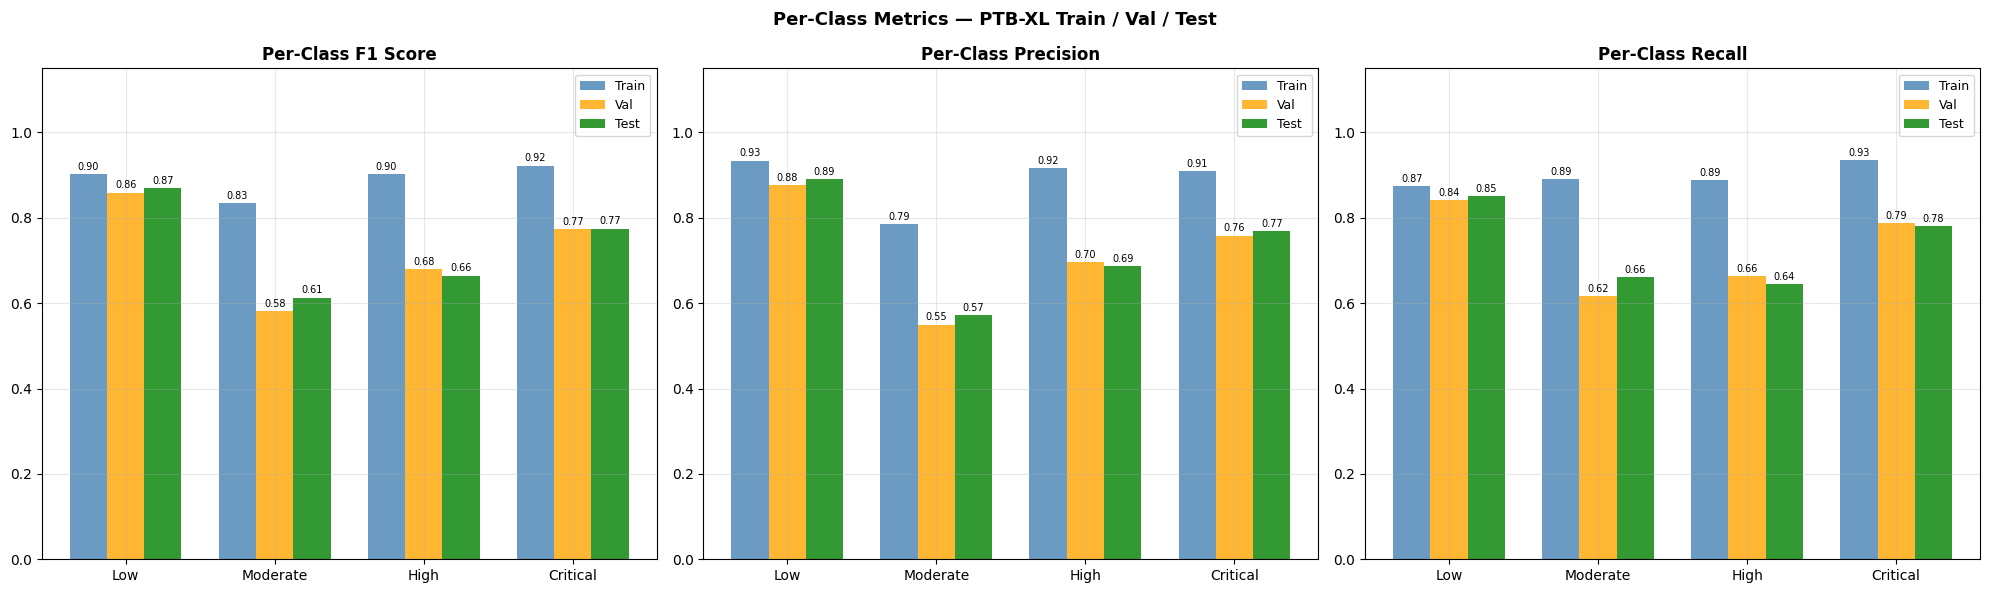

✅ Per-class metrics plot saved.


In [11]:
split_results = [
    (results_train, "Train", "steelblue"),
    (results_val,   "Val",   "orange"),
    (results_test,  "Test",  "green"),
]

class_names = ["Low", "Moderate", "High", "Critical"]
x = np.arange(4)
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metrics = [
    ("per_class_f1",   "Per-Class F1 Score"),
    ("per_class_prec", "Per-Class Precision"),
    ("per_class_rec",  "Per-Class Recall"),
]

for ax, (key, title) in zip(axes, metrics):
    for i, (res, sname, color) in enumerate(split_results):
        vals = res[key]
        bars = ax.bar(x + i * width, vals, width, label=sname, color=color, alpha=0.8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.2f}", ha="center", fontsize=7)
    ax.set_xticks(x + width)
    ax.set_xticklabels(class_names)
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle("Per-Class Metrics — PTB-XL Train / Val / Test",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "perclass_metrics_all_splits.png", dpi=150)
plt.show()
print("✅ Per-class metrics plot saved.")


## Step 3: Confusion Matrices — All Three Splits

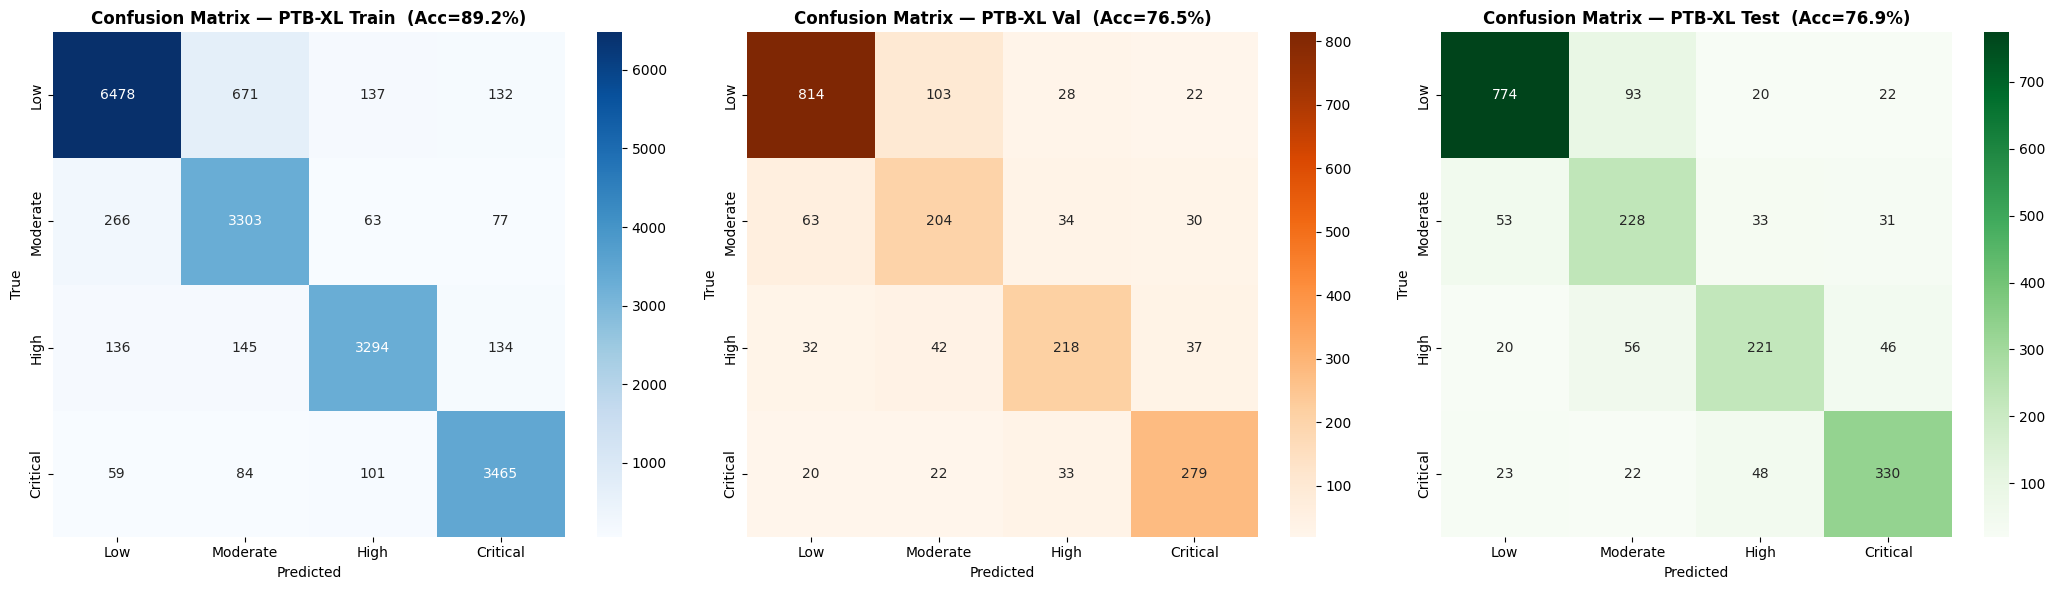

✅ Confusion matrices saved.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
cmaps     = ["Blues", "Oranges", "Greens"]

for ax, (res, sname, _), cmap in zip(axes, split_results, cmaps):
    cm = confusion_matrix(res["_true"], res["_preds"], labels=[0,1,2,3])
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["Low","Moderate","High","Critical"],
                yticklabels=["Low","Moderate","High","Critical"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — PTB-XL {sname}  "
                 f"(Acc={res['accuracy']*100:.1f}%)", fontweight="bold")

plt.tight_layout()
plt.savefig(SAVE_DIR / "confusion_matrices_all_splits.png", dpi=150)
plt.show()
print("✅ Confusion matrices saved.")


## Step 4: ROC & PR Curves — All Three Splits

In [20]:
print("DEBUG — split_results length right now:", len(split_results))

DEBUG — split_results length right now: 3


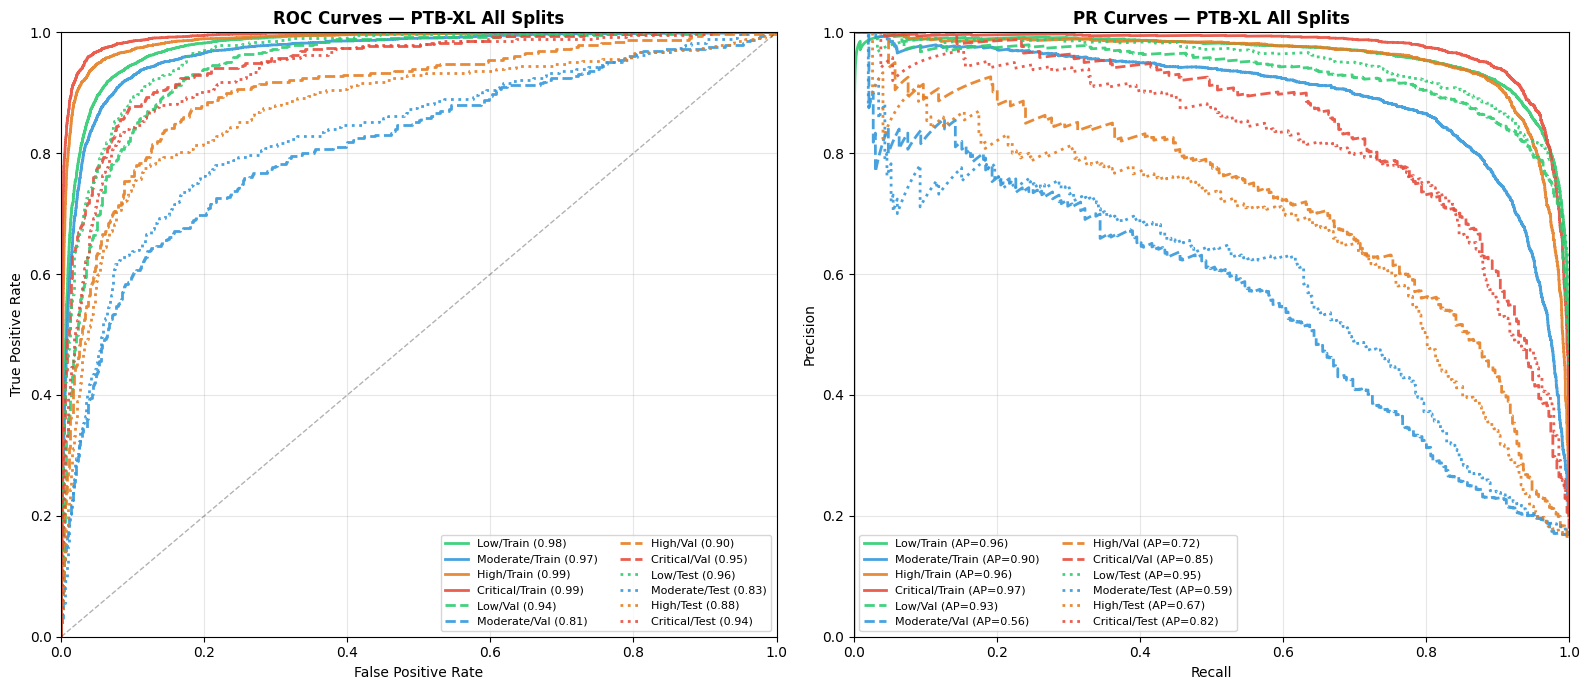

✅ ROC/PR curves saved.


In [22]:
from sklearn.preprocessing import label_binarize

cls_colors = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]
split_styles = ["-", "--", ":"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for (res, sname, _), linestyle in zip(split_results, split_styles):
    y_bin = label_binarize(res["_true"], classes=[0, 1, 2, 3])
    for k, color in zip(range(4), cls_colors):
        if np.all(y_bin[:, k] == 0) or np.all(y_bin[:, k] == 1):
            continue
        try:
            fpr, tpr, _ = roc_curve(y_bin[:, k], res["_probs"][:, k])
            auc_k = roc_auc_score(y_bin[:, k], res["_probs"][:, k])
            axes[0].plot(
                fpr,
                tpr,
                color=color,
                linestyle=linestyle,
                linewidth=2,
                alpha=0.9,
                label=f"{RISK_LABELS[k]}/{sname} ({auc_k:.2f})"
            )
        except Exception as e:
            print(f"⚠️ Skipped ROC class {k} for {sname}: {e}")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1)
axes[0].set_title("ROC Curves — PTB-XL All Splits", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8, ncol=2, loc="lower right")
axes[0].grid(True, alpha=0.3)

for (res, sname, _), linestyle in zip(split_results, split_styles):
    y_bin = label_binarize(res["_true"], classes=[0, 1, 2, 3])
    for k, color in zip(range(4), cls_colors):
        if np.all(y_bin[:, k] == 0) or np.all(y_bin[:, k] == 1):
            continue
        try:
            prec, rec, _ = precision_recall_curve(y_bin[:, k], res["_probs"][:, k])
            ap_k = average_precision_score(y_bin[:, k], res["_probs"][:, k])
            axes[1].plot(
                rec,
                prec,
                color=color,
                linestyle=linestyle,
                linewidth=2,
                alpha=0.9,
                label=f"{RISK_LABELS[k]}/{sname} (AP={ap_k:.2f})"
            )
        except Exception as e:
            print(f"⚠️ Skipped PR class {k} for {sname}: {e}")

axes[1].set_title("PR Curves — PTB-XL All Splits", fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8, ncol=2, loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / "roc_pr_all_splits.png", dpi=150)
plt.show()
print("✅ ROC/PR curves saved.")

## Step 5: Calibration Curves & Reliability Diagrams

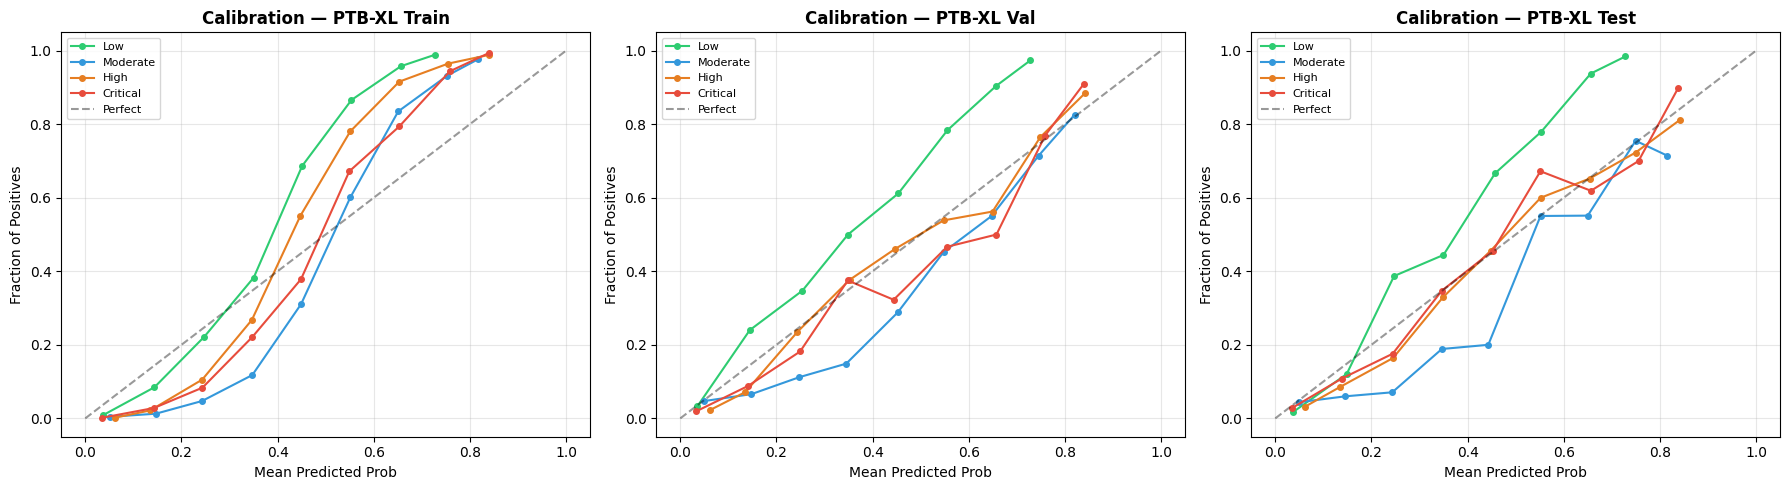

✅ Calibration curves saved.


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (res, sname, color) in zip(axes, split_results):
    y_bin = label_binarize(res["_true"], classes=[0,1,2,3])
    for k, cls_color in zip(range(4), cls_colors):
        try:
            frac_pos, mean_pred = calibration_curve(
                y_bin[:, k], res["_probs"][:, k],
                n_bins=10, strategy="uniform"
            )
            ax.plot(mean_pred, frac_pos, marker="o", color=cls_color,
                    label=RISK_LABELS[k], markersize=4)
        except Exception:
            pass

    ax.plot([0,1],[0,1], "k--", alpha=0.4, label="Perfect")
    ax.set_title(f"Calibration — PTB-XL {sname}", fontweight="bold")
    ax.set_xlabel("Mean Predicted Prob")
    ax.set_ylabel("Fraction of Positives")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / "calibration_all_splits.png", dpi=150)
plt.show()
print("✅ Calibration curves saved.")


## Step 6: Summary Comparison Table — PTB-XL + INCART


Full Dataset Comparison Table
Dataset                        Accuracy   Macro F1    ROC-AUC      MCC    Kappa
-------------------------------------------------------------------------------
PTB-XL Train (seen)              89.19%     0.8903     0.0000   0.8518   0.8509
PTB-XL Val                       76.48%     0.7230     0.0000   0.6547   0.6542
PTB-XL Test (held-out)           76.88%     0.7306     0.0000   0.6708   0.6702
INCART (cross-dataset)           46.50%     0.3487     0.6685   0.3293   0.2805


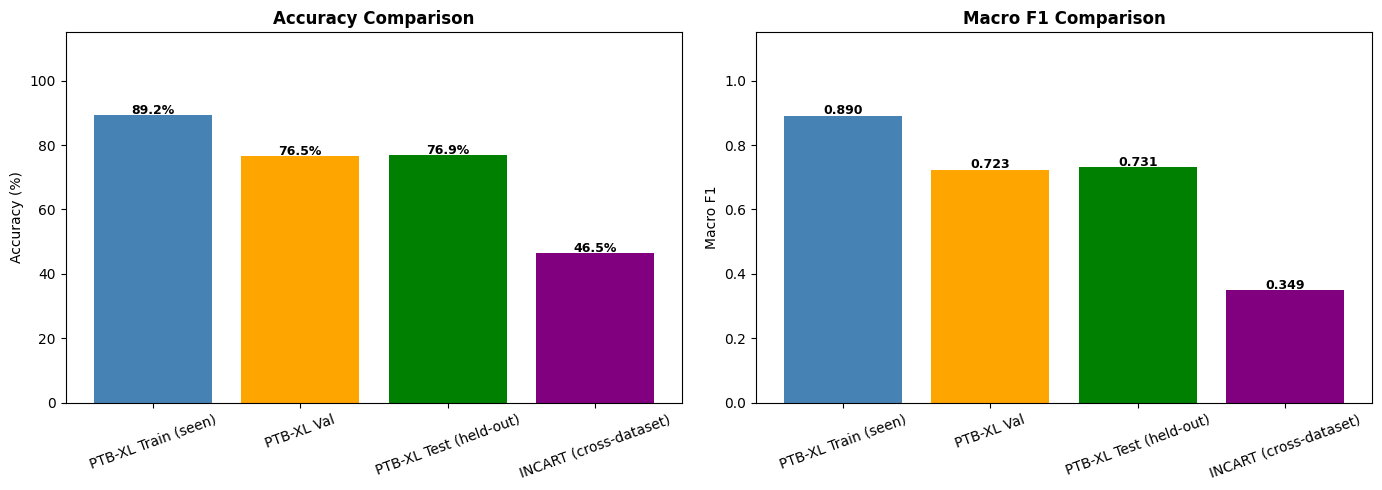


NOTEBOOK 6b COMPLETE ✅
Saved:
  ECG_Project\data/train_eval_results.json
  ECG_Project\data/perclass_metrics_all_splits.png
  ECG_Project\data/confusion_matrices_all_splits.png
  ECG_Project\data/roc_pr_all_splits.png
  ECG_Project\data/calibration_all_splits.png
  ECG_Project\data/dataset_comparison_bar.png
Next → Notebook 7: Edge-AI Optimization


In [24]:
# Load INCART results if available
cross_path = SAVE_DIR / "crossdataset_results.json"
cross = {}
if cross_path.exists():
    with open(cross_path) as f:
        cross = json.load(f)

print("\nFull Dataset Comparison Table")
header = f"{'Dataset':<28} {'Accuracy':>10} {'Macro F1':>10} {'ROC-AUC':>10} {'MCC':>8} {'Kappa':>8}"
print(header)
print("-" * len(header))

rows = [
    ("PTB-XL Train (seen)",   results_train["accuracy"], results_train["macro_f1"],
     results_train["roc_auc"], results_train["mcc"], results_train["kappa"]),
    ("PTB-XL Val",            results_val["accuracy"],   results_val["macro_f1"],
     results_val["roc_auc"],   results_val["mcc"],   results_val["kappa"]),
    ("PTB-XL Test (held-out)",results_test["accuracy"],  results_test["macro_f1"],
     results_test["roc_auc"],  results_test["mcc"],  results_test["kappa"]),
    ("INCART (cross-dataset)",
     cross.get("incart_accuracy", 0), cross.get("incart_macro_f1", 0),
     cross.get("incart_roc_auc", 0),  cross.get("incart_mcc", 0), cross.get("incart_kappa", 0)),
]

for name, acc, f1, auc, mcc_, kap in rows:
    print(f"{name:<28} {acc*100:>9.2f}% {f1:>10.4f} {auc:>10.4f} {mcc_:>8.4f} {kap:>8.4f}")

# Bar chart summary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names     = [r[0] for r in rows]
accs      = [r[1] * 100 for r in rows]
f1s       = [r[2] for r in rows]
bar_cols  = ["steelblue", "orange", "green", "purple"]

b1 = axes[0].bar(names, accs, color=bar_cols)
for bar, val in zip(b1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Accuracy Comparison", fontweight="bold")
axes[0].set_ylabel("Accuracy (%)"); axes[0].set_ylim(0, 115)
axes[0].tick_params(axis="x", rotation=20)

b2 = axes[1].bar(names, f1s, color=bar_cols)
for bar, val in zip(b2, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("Macro F1 Comparison", fontweight="bold")
axes[1].set_ylabel("Macro F1"); axes[1].set_ylim(0, 1.15)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(SAVE_DIR / "dataset_comparison_bar.png", dpi=150)
plt.show()

# Save train eval results
train_eval_results = {
    "ptbxl_train": {k: v for k, v in results_train.items() if not k.startswith("_")},
    "ptbxl_val"  : {k: v for k, v in results_val.items()   if not k.startswith("_")},
    "ptbxl_test" : {k: v for k, v in results_test.items()  if not k.startswith("_")},
}
with open(SAVE_DIR / "train_eval_results.json", "w") as f:
    json.dump(train_eval_results, f, indent=2)

print()
print("NOTEBOOK 6b COMPLETE ✅")
print("Saved:")
print(f"  {SAVE_DIR}/train_eval_results.json")
print(f"  {SAVE_DIR}/perclass_metrics_all_splits.png")
print(f"  {SAVE_DIR}/confusion_matrices_all_splits.png")
print(f"  {SAVE_DIR}/roc_pr_all_splits.png")
print(f"  {SAVE_DIR}/calibration_all_splits.png")
print(f"  {SAVE_DIR}/dataset_comparison_bar.png")
print("Next → Notebook 7: Edge-AI Optimization")
